In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [2]:
citra1 = cv.imread('assets/potongan1.jpg')
citra2 = cv.imread('assets/potongan2.jpg')
citra3 = cv.imread('assets/potongan3.jpg')
citra4 = cv.imread('assets/potongan4.jpg')

Text(0.5, 1.0, 'potongan 4')

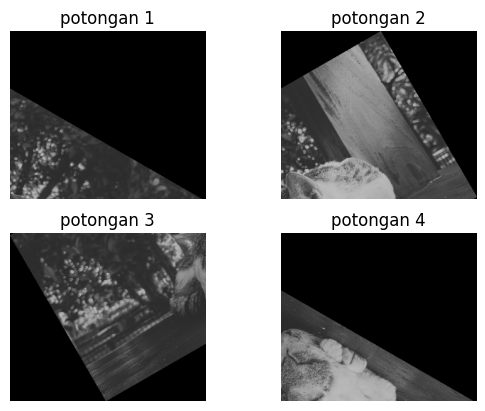

In [3]:
plt.subplot(2, 2, 1)
plt.imshow(citra1)
plt.axis('off')
plt.title('potongan 1')

plt.subplot(2, 2, 2)
plt.imshow(citra2)
plt.axis('off')
plt.title('potongan 2')

plt.subplot(2, 2, 3)
plt.imshow(citra3)
plt.axis('off')
plt.title('potongan 3')

plt.subplot(2, 2, 4)
plt.imshow(citra4)
plt.axis('off')
plt.title('potongan 4')


In [4]:
gray_a = cv.cvtColor(citra1, cv.COLOR_BGR2GRAY)
gray_b = cv.cvtColor(citra2, cv.COLOR_BGR2GRAY)
gray_c = cv.cvtColor(citra3, cv.COLOR_BGR2GRAY)
gray_d = cv.cvtColor(citra4, cv.COLOR_BGR2GRAY)


Text(0.5, 1.0, 'potongan 4')

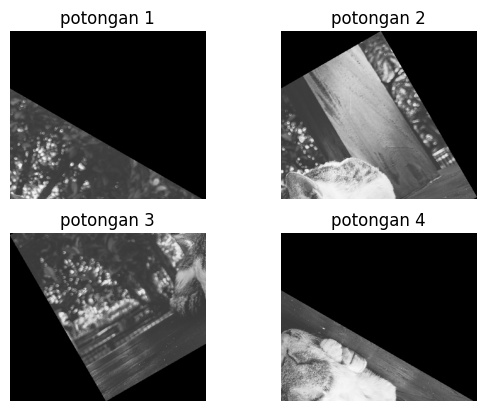

In [6]:
plt.subplot(2, 2, 1)
plt.imshow(gray_a, cmap = "gray")
plt.axis('off')
plt.title('potongan 1')

plt.subplot(2, 2, 2)
plt.imshow(gray_b, cmap = "gray")
plt.axis('off')
plt.title('potongan 2')

plt.subplot(2, 2, 3)
plt.imshow(gray_c, cmap = "gray")
plt.axis('off')
plt.title('potongan 3')

plt.subplot(2, 2, 4)
plt.imshow(gray_d, cmap = "gray")
plt.axis('off')
plt.title('potongan 4')


In [9]:
def flipping(image, mode='x'):
    h, w = image.shape
    hasil = np.zeros((h, w), dtype = image.dtype)
    for i in range (h):
        for j in range (w):
            if mode == 'x':
                hasil[i, j] = image[h-1-i, j]
            elif mode == 'y':
                hasil[i, j] = image[i, w-1-j]
    return hasil

In [12]:
flip_citra1 = flipping(gray_a, 'y')
flip_citra4 = flipping(gray_d, 'x')

Text(0.5, 1.0, 'flip vertical gambar 4')

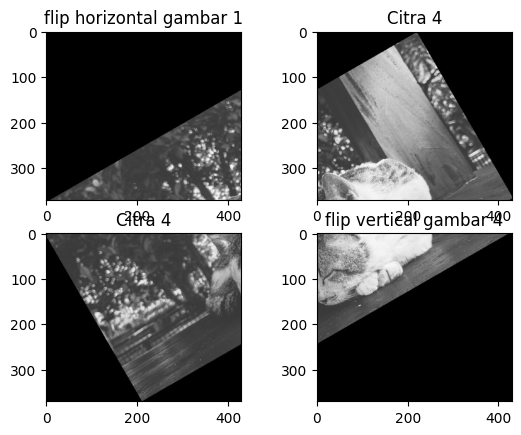

In [14]:
plt.subplot(2, 2, 1)
plt.imshow(flip_citra1, cmap = "gray")
plt.title('flip horizontal gambar 1')

plt.subplot(2, 2, 2)
plt.imshow(gray_b, cmap = "gray")
plt.title('Citra 4')

plt.subplot(2, 2, 3)
plt.imshow(gray_c, cmap = "gray")
plt.title('Citra 4')

plt.subplot(2, 2, 4)
plt.imshow(flip_citra4, cmap = "gray")
plt.title('flip vertical gambar 4')

In [15]:
def merge_horizontal(citra_1, citra_2): 
    c1, c2 = np.array(citra_1), np.array(citra_2) 
    tinggi = max(c1.shape[0], c2.shape[0]) 
    lebar = c1.shape[1] + c2.shape[1] 
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype) 
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1 
    hasil[0:c2.shape[0], c1.shape[1]:] = c2 
    return hasil 

def merge_vertikal(citra_1, citra_2): 
    c1, c2 = np.array(citra_1), np.array(citra_2) 
    tinggi = c1.shape[0] + c2.shape[0] 
    lebar = max(c1.shape[1], c2.shape[1]) 
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype) 
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1 
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2 
    return hasil 


In [18]:
mergeAC = merge_vertikal(flip_citra1, gray_c)
mergeBD = merge_vertikal(gray_b, flip_citra4)

mergeABCD = merge_horizontal(mergeAC, mergeBD)

Text(0.5, 1.0, 'Citra Setelah Digabungkan')

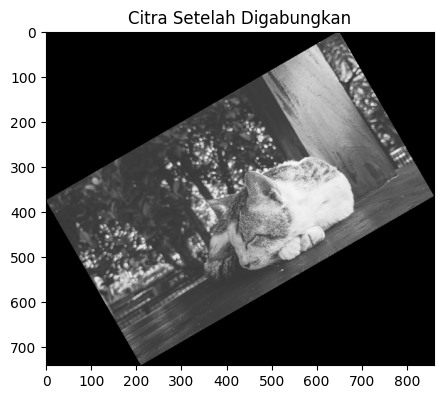

In [20]:
plt.figure(figsize=(5, 5))
plt.imshow(mergeABCD, cmap = 'gray')
plt.title('Citra Setelah Digabungkan')

In [21]:
citra5 = cv.imread('assets/inv.jpg')

Text(0.5, 1.0, 'fliip horizontal gambar 1')

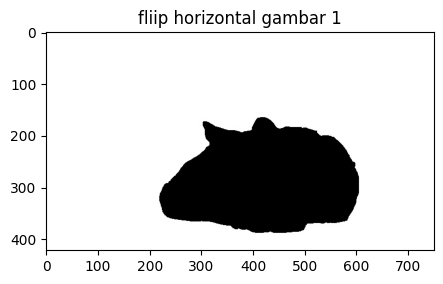

In [24]:
plt.figure(figsize=(5, 5))
plt.imshow(citra5)
plt.title('fliip horizontal gambar 1')

In [ ]:
def rotasi(image, val): 
    h, w = image.shape
    val = int(val) % 360  
    if val == 0: return image 
    elif val == 90: 
        rot = np.zeros((w, h), dtype=image.dtype) 
        for i in range(h): 
            for j in range(w): 
                rot[j, h - 1 - i] = image[i, j] 
        return rot 
    elif val == 180: 
        rot = np.zeros_like(image, dtype=image.dtype) 
        for i in range(h): 
            for j in range(w): 
                rot[h - 1 - i, w - 1 - j] = image[i, j] 
        return rot 
    elif val == 270:  
        rot = np.zeros((w, h), dtype=image.dtype) 
        for i in range(h): 
            for j in range(w): 
                rot[w - 1 - j, i] = image[i, j] 
        return rot 
    elif val == 330:
        rot = np.zeros((h, w), dtype=image.dtype)
        cx, cy = w // 2, h // 2

        rad = -30 * np.pi / 180  
        cos = np.cos(rad)
        sin = np.sin(rad)
        for i in range(h): 
            for j in range(w): 
                xr = int(cos * x - sin * y + cx)
                yr = int(sin * x + cos * y + cy)
        return rot 
    
    return image 

In [48]:
rotasiA = rotasi(citra5, 90)

plt.figure(figsize=(5, 5))
plt.imshow(rotasiA, cmap = "gray")
plt.axis('off')
plt.title('Citra A')


ValueError: too many values to unpack (expected 2, got 3)